In [1]:
import numpy as np
from pyemma import msm, plots
import matplotlib.pyplot as plt
import itertools

import pandas as pd

# MFPT

In [23]:
alpha_l = (50, 30) #(phi,psi)
alpha_r = (-70, -20)
beta = (-130,170)
c5 = (-90, 170)
c7eq = (-80,70)
c7ax = (70,-50)

bins=np.arange(-0.9, 1.1, 0.1)
def state_map(data, choice):
    if choice == 'phi':
        val = data[0]
    elif choice == 'psi':
        val = data[1]
    sin_val = np.sin(val/180*np.pi)
    # find the bin where the sin_val belongs to
    state = np.digitize(sin_val, bins)
    return state


In [112]:
task = 'psi' 
datapath = f'/home/wzengad/projects/MD_code/data/{task}/train'
train=np.loadtxt(datapath, dtype=int).reshape(-1)
# test = np.loadtxt(f'/home/wzengad/projects/MD_code/data/{task}/test', dtype=int).reshape(-1)

alpha_l_state = state_map(alpha_l, task)
alpha_r_state = state_map(alpha_r, task)
beta_state = state_map(beta, task)
c5_state = state_map(c5, task)
c7ax_state = state_map(c7ax, task)
c7eq_state = state_map(c7eq, task)

In [103]:
interval=1
lag_limit = 200 
lag_times=range(int(10/(interval*0.1)),int(lag_limit/(interval*0.1)),int(10/(interval*0.1)))

train_interval = train.reshape(-1, interval).T.flatten()

In [119]:
# for gpt
# pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/{task}/trans_gpt/Label0.0_window50_interval{interval}_lr0.0005_emb_dim128_l100_block2_scheduled/category/epoch60_100000_valid_interval{interval}'
# for lstm
pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/{task}/lstm/Label0.0_sparse50_interval1_lr0.001_l100_units512_emb128_no_pos/category/epoch150_100000_valid_interval1'
def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]

from pyemma import msm
msm_nrev = msm.estimate_markov_model(train, 100)
msm_nrev_pred = msm.estimate_markov_model(pred_traj, int(100/interval))

In [120]:
print(f'alpha_l to alpha_r: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: generated trajectory: {msm_nrev_pred.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c5_state,alpha_l_state)*interval}')
print(f'c7eq to c7ax: generated trajectory: {msm_nrev_pred.mfpt(c7eq_state,c7ax_state)*interval}')
print(f'reverse: generated trajectory: {msm_nrev_pred.mfpt(c7ax_state,c7eq_state)*interval}')

alpha_l to alpha_r: generated trajectory: 3268.522559469846
reverse: generated trajectory: 934.2601328359254
alpha_l to beta: generated trajectory: 1592.2032925639323
reverse: generated trajectory: 879.3632737756759
alpha_l to c5: generated trajectory: 1592.2032925639323
reverse: generated trajectory: 879.3632737756759
c7eq to c7ax: generated trajectory: 10150.642231010735
reverse: generated trajectory: 3441.047366645398


In [61]:
print(f'alpha_l to alpha_r: md: {msm_nrev.mfpt(alpha_l_state,alpha_r_state)*interval}')
print(f'reverse: md: {msm_nrev.mfpt(alpha_r_state,alpha_l_state)*interval}')
print(f'alpha_l to beta: md: {msm_nrev.mfpt(alpha_l_state,beta_state)*interval}')
print(f'reverse: md: {msm_nrev.mfpt(beta_state,alpha_l_state)*interval}')
print(f'alpha_l to c5: md: {msm_nrev.mfpt(alpha_l_state,c5_state)*interval}')
print(f'reverse: md: {msm_nrev.mfpt(c5_state,alpha_l_state)*interval}')
print(f'c7eq to c7ax: md: {msm_nrev.mfpt(c7eq_state,c7ax_state)*interval}')
print(f'reverse: md: {msm_nrev.mfpt(c7ax_state,c7eq_state)*interval}')

alpha_l to alpha_r: md: 3779.166819397495
reverse: md: 1021.4192408520275
alpha_l to beta: md: 1526.7686770252096
reverse: md: 887.0538887162592
alpha_l to c5: md: 1526.7686770252096
reverse: md: 887.0538887162592
c7eq to c7ax: md: 12653.739189866996
reverse: md: 3490.564997455037


In [17]:
# (a,b) = (3,15) if task=='phi' else (0,19)
print(f'alpha_l to alpha_r: MD trajectory: {round(msm_nrev.mfpt(a,b))} , predict trajectory: {round(msm_nrev_pred.mfpt(a,b)*interval)}')
print(f'reverse: MD trajectory: {round(msm_nrev.mfpt(b,a))} , predict trajectory: {round(msm_nrev_pred.mfpt(b,a)*interval)}')

alpha_l to alpha_r: MD trajectory: 414865.0 , predict trajectory: 601410.0
reverse: MD trajectory: 11139.0 , predict trajectory: 15887.0


In [ ]:
for a in range(20):
    for b in range(a+1, 20):
        if msm_nrev.mfpt(a,b) // msm_nrev.mfpt(b,a) <=50 and msm_nrev.mfpt(a,b) // msm_nrev.mfpt(b,a) >=30:
            print(a,b)
            print(f'alpha_l to alpha_r: MD trajectory: {msm_nrev.mfpt(a,b)} , predict trajectory: {msm_nrev_pred.mfpt(a,b)*interval}')
            print(f'reverse: MD trajectory: {msm_nrev.mfpt(b,a)} , predict trajectory: {msm_nrev_pred.mfpt(b,a)*interval}')

# ITS

In [2]:
task = 'psi' 
datapath = f'../data/{task}/train'
train=np.loadtxt(datapath, dtype=int).reshape(-1)
test = np.loadtxt(f'../data/{task}/test', dtype=int).reshape(-1)


In [4]:
lag_times

range(100, 300, 100)

In [28]:
# for phi: Label0.0_window50_interval{interval}_lr0.0005_emb_dim128_l100_block2_scheduled, epoch200
# for psi: Label0.0_window50_interval{interval}_lr0.0005_emb_dim128_l100_block2_scheduled, epoch80
pred_path = f'../results/{task}/trans_gpt/Label0.0_window50_interval{interval}_lr0.0005_emb_dim128_l100_block2_scheduled/category/epoch80_100000_valid_interval{interval}'
# pred_path = f'/home/wzengad/projects/MD_code/LSTM/results/RMSD/trans_gpt/Label0.0_window50_interval{interval}_lr{lr}_l100_block3_no_pos_scheduled/category/epoch280_100000_valid_interval{interval}'
def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data
pred_traj = [load_data(pred_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]

lstm_path = f'../results/{task}/lstm/Label0.0_sparse50_interval1_lr0.001_l100_units512_emb128_no_pos/category/epoch150_100000_valid_interval1'
pred_lstm = [load_data(lstm_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]

In [25]:
from msmbuilder.msm import MarkovStateModel
for lagtime in range(50, 2001, 100):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=3, verbose=False, reversible_type="transpose")
    msm.fit(train)
    print(lagtime, end=" ")
    for i in range(3):
        print(msm.timescales_[i], end=" ")
    print("\n", end="")

50 77.83041610684707 11.021892986842634 10.297831312020241 
150 182.54188082642116 27.57130347846837 24.60188039480925 
250 254.85569388868925 44.15580800479691 42.58437269848016 
350 307.87360114262225 63.850679475961634 58.61669654754725 
450 346.4848773625567 82.01285808635664 76.08166194533078 
550 377.30095487593405 100.88758325218218 87.21911478500593 
650 401.39588797891224 117.31074275163317 107.45224343933306 
750 421.8707144643087 134.19403537044968 118.41342427742542 
850 438.65297814072034 158.09876867426647 140.75567794754235 
950 452.93966146155304 175.71802126294344 153.4950319313977 
1050 465.7805815612197 192.55695683943256 169.98753958588279 
1150 477.3131592306928 200.09756042019353 177.44650409716064 
1250 490.705137537915 226.21819008647196 195.20528873850577 
1350 503.42406444837746 240.47570744714318 216.9858203356021 
1450 516.1589530661369 252.37210054521134 240.96819292791088 
1550 526.1129155918347 282.80264116246957 244.20203286540828 
1650 541.2151833387335

In [26]:
from msmbuilder.msm import MarkovStateModel
for lagtime in range(50, 2001, 100):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=3, verbose=False, reversible_type="transpose")
    msm.fit(pred_traj)
    print(lagtime, end=" ")
    for i in range(3):
        print(msm.timescales_[i], end=" ")
    print("\n", end="")

50 81.22552884623018 10.169307196596584 9.64473345124046 
150 181.38399975189645 27.43612681007247 25.793718942237962 
250 239.43693810919373 47.06178184237324 44.63344421486573 
350 274.8833584482136 67.12040906271164 63.6680422525034 
450 300.5993232680449 79.49000274547184 78.92783291435907 
550 316.8788749220141 101.7278155942314 96.67327927773601 
650 332.26850716833917 120.40701706889209 115.88506572486736 
750 344.6891567534663 133.25177642456364 130.65803264112083 
850 354.6015828366314 154.70647155120258 148.74432952257553 
950 369.97692254936106 173.8007473803237 166.6044079939449 
1050 386.2719002611927 190.24720166552137 182.8118122093265 
1150 404.1410072778094 206.65673299573052 205.34308844884822 
1250 418.4722606712837 228.69292864903792 216.92804277347125 
1350 425.8781567170008 249.93411703836244 245.7833505401627 
1450 443.6611922267738 261.78678357729274 253.9103049048102 
1550 465.50921307696336 282.0942520853233 278.98471184722496 
1650 487.880451493843 300.613684

In [29]:
from msmbuilder.msm import MarkovStateModel
for lagtime in range(50, 2001, 100):
    msm = MarkovStateModel(lag_time=lagtime, n_timescales=3, verbose=False, reversible_type="transpose")
    msm.fit(pred_lstm)
    print(lagtime, end=" ")
    for i in range(3):
        print(msm.timescales_[i], end=" ")
    print("\n", end="")

50 60.051069876661096 10.344846714078637 9.592863273760853 
150 88.53695098156702 26.947793459563957 26.352626005821193 
250 96.7864525991396 45.323166638016794 43.96887083978508 
350 94.76668349764192 63.48690279476467 61.08975930242717 
450 97.64738833957679 83.27486971729252 79.11928196066283 
550 108.20360216282296 98.0681407030246 95.8713968710182 
650 120.73704776348785 117.88670977236755 112.66903163119225 
750 133.22518439269217 130.83686933030535 126.00596350556437 
850 152.5077914404305 149.61019309171232 140.8897022635041 
950 172.71004429984032 164.82817800648175 158.88390247228784 
1050 203.85508687947893 191.74140207878975 184.91455012812443 
1150 228.74762527767342 209.77289775546663 198.22318379642073 
1250 244.18260188246245 226.26102223137008 224.71579673885097 
1350 266.74782534028446 251.22097245445667 245.5164646002063 
1450 262.1915982423787 247.1424519229151 240.09605648481178 
1550 284.26616920811335 271.40289247119085 266.7336275445733 
1650 295.3996538513654 2

In [ ]:
interval=1
lag_limit = 10
lag_times=range(int(1/(interval*0.1)),int(lag_limit/(interval*0.1)),int(5/(interval*0.1)))

train_interval = train.reshape(-1, interval).T.flatten()
train_interval_ts = msm.its(train_interval, lag_times, nits=3, show_progress=False)


In [ ]:
pred_gpt = msm.its(pred_traj, lag_times, nits=3, show_progress=False)

In [9]:
pred_lstm = msm.its(pred_lstm, lag_times, nits=3, show_progress=False)

In [11]:
import matplotlib.style as style 
import matplotlib
# style.available

# style.use('seaborn-paper') #sets the size of the charts
# # style.use('ggplot')
# plt.rcParams["font.family"] = "DejaVu Serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]

In [ ]:
baseline = train_interval_ts.timescales*interval*0.1
gpt = pred_gpt.timescales*interval*0.1
lstm = pred_lstm.timescales*interval*0.1
lag_times_x = np.array(lag_times)*interval*0.1

draw = pd.DataFrame([lag_times_x.T, baseline[:,0],gpt[:,0],lstm[:,0],baseline[:,1], gpt[:,1],lstm[:,1],baseline[:,2], gpt[:,2],lstm[:,2]]).T
draw.columns = ['lag_times', 'baseline_1', 'gpt_1', 'lstm_1', 'baseline_2', 'gpt_2', 'lstm_2', 'baseline_3', 'gpt_3', 'lstm_3']
draw.to_csv(f'/home/wzengad/projects/MD_code/Fig_data/draw/{task}_its.csv', index=False)

In [17]:
baseline

array([[13.48702435,  1.91429875,  1.75613834],
       [22.23310327,  3.6675309 ,  3.38226196]])

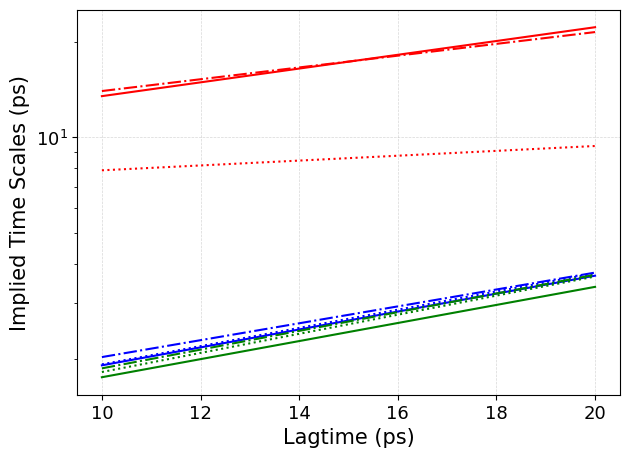

In [15]:
marker = itertools.cycle(('o', 'v', '^', '<', '>', 's', '8', 'p'))
baseline = train_interval_ts.timescales*interval*0.1
gpt = pred_gpt.timescales*interval*0.1
lstm = pred_lstm.timescales*interval*0.1
lag_times_x = np.array(lag_times)*interval*0.1
# set figsize to (6,4)
plt.figure(figsize=(7,5))
plt.plot(lag_times_x, baseline[:,0],'r', label='1st ITS Baseline')
plt.plot(lag_times_x, gpt[:,0], 'r-.',label='1st ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,0], 'r:',label='1st ITS LSTM')

plt.plot(lag_times_x, baseline[:,1],'b', label='2nd ITS Baseline')
plt.plot(lag_times_x, gpt[:,1], 'b-.',label='2nd ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,1], 'b:',label='2nd ITS LSTM')

plt.plot(lag_times_x, baseline[:,2],'g', label='3rd ITS Baseline')
plt.plot(lag_times_x, gpt[:,2], 'g-.',label='3rd ITS nano-GPT')
plt.plot(lag_times_x, lstm[:,2], 'g:',label='3rd ITS LSTM')

if task == 'phi':
    plt.legend(loc=(1.04, 0), fontsize=13)
if task == 'psi': 
    plt.ylabel('Implied Time Scales (ps)', fontsize=15)
plt.yscale("log")
plt.xlabel('Lagtime (ps)', fontsize=15)
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.yticks(fontsize =13)
plt.xticks(fontsize =13)
plt.show()
# plt.savefig(f'/home/wzengad/projects/MD_code/Fig/ITS_{task}_{interval}.pdf', format='pdf', dpi=600, bbox_inches='tight',pad_inches = 0.05)
# plt.savefig(f'/home/wzengad/projects/MD_code/Fig/ITS_{task}_{interval}.pdf', format='pdf', dpi=600,pad_inches = 0.05)

In [ ]:
# marker = itertools.cycle(('o', 'v', '^', '<', '>', 's', '8', 'p'))
# baseline = train_interval_ts.timescales*interval*0.1
# gpt = pred_gpt.timescales*interval*0.1
# # lstm = pred_lstm.timescales*interval*0.1
# lag_times_x = np.array(lag_times)*interval*0.1

# plt.plot(lag_times_x, baseline[:,0],'r', label='1st ITS Baseline')
# plt.plot(lag_times_x, gpt[:,0], 'r:',label='1st ITS nano-GPT')

# plt.plot(lag_times_x, baseline[:,1],'b', label='2nd ITS Baseline')
# plt.plot(lag_times_x, gpt[:,1], 'b:',label='2nd ITS nano-GPT')

# plt.plot(lag_times_x, baseline[:,2],'g', label='3rd ITS Baseline')
# plt.plot(lag_times_x, gpt[:,2], 'g:',label='3rd ITS nano-GPT')

# plt.legend(loc=(1.04, 0))
# plt.ylabel('Implied Time Scales (ps)')
# plt.yscale("log")
# plt.xlabel('Lagtime (ps)')
# plt.show()
# # plt.savefig(f'/home/wzengad/projects/MD_code/Fig/ITS_{task}_{interval}.pdf', format='pdf',bbox_inches='tight', dpi=600, pad_inches = 0.05)

# Free energy

In [127]:
task = 'phi' 
datapath = f'/home/wzengad/projects/MD_code/data/{task}/train'
train=np.loadtxt(datapath, dtype=int).reshape(-1)
# test = np.loadtxt(f'/home/wzengad/projects/MD_code/data/{task}/test', dtype=int).reshape(-1)

def load_data(path):
    data = np.loadtxt(path, dtype= int)
    # data = Rm_peaks_steps(data, 100)
    return data

In [128]:
# for lstm
interval=1
lstm_path = f'/home/wzengad/projects/MD_code/LSTM/results/{task}/lstm/Label0.0_sparse50_interval1_lr0.001_l100_units512_emb128_no_pos/category/epoch50_100000_valid_interval1'
lstm = [load_data(lstm_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]


In [ ]:

gpt_path = f'/home/wzengad/projects/MD_code/LSTM/results/{task}/trans_gpt/Label0.0_window50_interval{interval}_lr0.0005_emb_dim128_l100_block2_scheduled/category/epoch60_100000_valid_interval{interval}'
gpt = [load_data(gpt_path + f'/no_gen_pos_prediction_{i}') for i in range(20)]


In [ ]:
def state_count(data, type = 'other'):
    if type == 'other':
        all_data = np.concatenate(data)
    else:
        all_data = data
    all_data = pd.DataFrame(all_data)
    res = all_data[0].value_counts()
    # make the index of res as a new colomn and sort the dataframe by the index
    res_df = res.rename_axis('state').reset_index(name='counts').sort_values(by='state')
    # add a new column in res_df to store the probability of each state
    res_df['prob'] = res_df['counts']/res_df['counts'].sum()
    # add a new column as free energy as -kTln(prob)
    res_df['free_energy'] = -0.616 * np.log(res_df['prob'])  # 0.616 for Kcal/mol; 2.6 for kJ/mol
    return res_df

In [ ]:
gpt_count = state_count(gpt)
lstm_count = state_count(lstm)
md_count = state_count(train, 'train')

In [ ]:
draw = pd.DataFrame([np.arange(-1,1,0.1),md_count['free_energy'],gpt_count['free_energy'],lstm_count['free_energy']]).T
draw.columns = ['x', 'md', 'gpt', 'lstm']
draw.to_csv(f'/home/wzengad/projects/MD_code/Fig_data/draw/{task}_free_energy.csv', index=False)

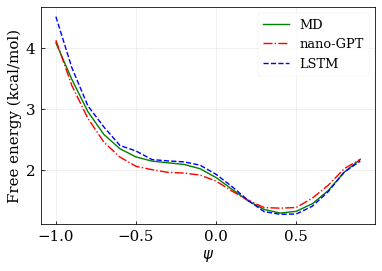

In [114]:
# plotting
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
fig, ax=plt.subplots(figsize=(6,4), nrows=1, ncols=1)
x = np.arange(-1,1,0.1)
ax.plot(x, md_count['free_energy'], linestyle='-', color='green', label='MD')
ax.plot(x, gpt_count['free_energy'], linestyle='-.', color='red', label='nano-GPT')
ax.plot(x, lstm_count['free_energy'], linestyle='--', color='blue', label='LSTM')

ax.tick_params(axis='both', which='both', labelsize=15, direction='in')
ax.set_xlabel(f'$\{task}$ ', size=15)
if task == 'psi':
    ax.set_ylabel('Free energy (kcal/mol)', size=15)
# ax.set_xlim(-np.pi*5, np.pi*5)
# ax.set_ylim(-1, 61)
ax.legend(loc='upper right', fontsize=13)
# if task == 'phi':
#     ax.legend(loc='upper left', fontsize=13)
# fig.tight_layout()
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
plt.savefig(f'/home/wzengad/projects/MD_code/Fig/fe_{task}.pdf', format='pdf', dpi=600, pad_inches = 0.05)
plt.show()

# Free energy landscape

In [1]:
from __future__ import absolute_import, division, print_function, unicode_literals
import tensorflow as tf
tf.compat.v1.enable_eager_execution() 
import numpy as np
import os
from bs4 import BeautifulSoup
import requests
import json
import time
# from lossT import sparse_categorical_crossentropy


In [2]:
phi=np.array([])
psi=np.array([])

def load_xvg(path):
    phi, psi = [], []
    with open(path) as f:
        for line in f:
            if line.startswith('#') or line.startswith('@'):
                continue

            cols = line.split()
            phi.append(float(cols[1]))
            psi.append(float(cols[0]))
    return (phi,psi)

for i in range(0,100):
    if i<10:
        url = f'/home/wzengad/projects/MD_code/data/phi_psi_raw/ala2-0.1ps-0{i}.xvg'
    else:
        url = f'/home/wzengad/projects/MD_code/data/phi_psi_raw/ala2-0.1ps-{i}.xvg'
    # data = np.loadtxt(url,comments=["@", '#'],unpack=True)
    (_phi, _psi) = load_xvg(url)

    phi=np.append(phi,_phi)
    psi=np.append(psi,_psi)

In [3]:
bins=np.arange(-180, 180, 1.8)

# idx_sin_phi = np.loadtxt('/home/wzengad/projects/MD_code/data/phi/train',dtype=int).reshape(-1)
# idx_sin_psi = np.loadtxt('/home/wzengad/projects/MD_code/data/psi/train',dtype=int).reshape(-1)
idx_sin_phi=np.digitize(phi, bins) 
idx_sin_psi=np.digitize(psi, bins) 

import pandas as pd
count=pd.DataFrame({'phi':idx_sin_phi,'psi':idx_sin_psi})
cnt=count.groupby(['phi','psi'])

test=cnt.agg(len)
data=np.zeros((len(bins),len(bins)))

import math
for i in range(len(bins)):
    for j in range((len(bins))):
        if (i,j) in test:
            data[i,j]=math.log10(test[(i,j)])   #i:phi,j:psi
data2=pd.DataFrame(data)

In [4]:
import matplotlib.style as style 
import matplotlib
import matplotlib.pyplot as plt
style.available
style.use('seaborn-paper') #sets the size of the charts
# style.use('ggplot')
matplotlib.rcParams['font.family'] = "serif"



Bad key text.latex.unicode in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 112 ('text.latex.unicode : False # use "ucs" and "inputenc" LaTeX packages for handling')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.4/matplotlibrc.template
or from the matplotlib source distribution

Bad key savefig.frameon in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 423 ('savefig.frameon : True')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.3.4/matplotlibrc.template
or from the matplotlib source distribution

Bad key pgf.debug in file /home/wzengad/anaconda3/envs/python36/lib/python3.6/site-packages/matplotlib/mpl-data/stylelib/_classic_test.mplstyle, line 444 ('pgf.debug           : False')
You probably need to 

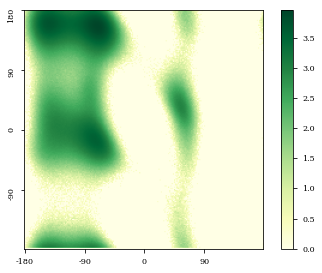

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)
yticklabels = [180, 90, 0, -90]
xticklabels = [-180, -90, 0, 90]

ax.set_yticks([0,50,100,150])
ax.set_yticklabels(yticklabels, rotation=90)
ax.set_xticks([0,50,100,150])
ax.set_xticklabels(xticklabels,)

im = ax.imshow(data[::-1,:], cmap='YlGn')
plt.colorbar(im)
plt.savefig('/home/wzengad/projects/MD_code/Fig/ala_heat.pdf', format='pdf', dpi=600, pad_inches = 0.05)



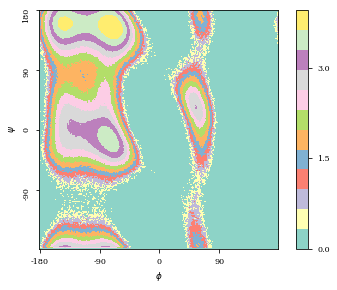

In [22]:


fig = plt.figure()
ax = fig.add_subplot(111)
yticklabels = [180, 90, 0, -90]
xticklabels = [-180, -90, 0, 90]

ax.set_yticks([0,50,100,150])
ax.set_yticklabels(yticklabels, rotation=90)

ax.set_xticks([0,50,100,150])
ax.set_xticklabels(xticklabels,)
ax.set_ylabel('$\psi$')
ax.set_xlabel('$\phi$')

im = ax.imshow(data[::-1,:], cmap=plt.get_cmap('Set3'))
cb = plt.colorbar(im)
from matplotlib import ticker
tick_locator = ticker.MaxNLocator(nbins=3)
cb.locator = tick_locator
cb.update_ticks()

plt.savefig('/home/wzengad/projects/MD_code/Fig/ala_heat.pdf', format='pdf', dpi=600, pad_inches = 0.05)



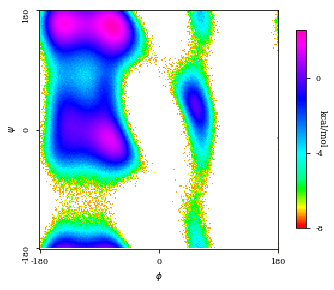

In [67]:
from matplotlib import ticker
import matplotlib.colors as mcolors

fig = plt.figure()
ax = fig.add_subplot(111)
yticklabels = [180,  0, -180]
xticklabels = [-180, 0, 180]
norm = mcolors.TwoSlopeNorm(vmin=data.min(), vcenter=(data.min() + data.max())//2, vmax = data.max())

ax.set_yticks([0,100,199])
ax.set_yticklabels(yticklabels, rotation=90)

ax.set_xticks([0,100,199])
ax.set_xticklabels(xticklabels,)
ax.set_ylabel('$\psi$')
ax.set_xlabel('$\phi$')

data_masked = np.ma.masked_where(data == 0, data)

# cmap choice see: https://matplotlib.org/2.0.2/examples/color/colormaps_reference.html
# im = ax.imshow(data[::-1,:], cmap='gist_rainbow', norm=norm)
im = ax.imshow(data_masked[::-1,:], interpolation = 'none', cmap='gist_rainbow', norm=norm)

# cb = plt.colorbar(im, shrink=0.83)

cb = plt.colorbar(im, shrink=0.83, ticks = [0, 2, 3.9])
tick_locator = ticker.MaxNLocator(nbins=3)
cb.locator = tick_locator
cb.update_ticks()
cb.ax.set_yticklabels(['0', '-4', '-8'])  # vertically oriented colorbar
cb.ax.set_ylabel('kcal/mol', rotation=270)
plt.savefig('/home/wzengad/projects/MD_code/Fig/ala_heat.pdf', format='pdf', dpi=600, pad_inches = 0.05)



In [53]:
data.max()

3.964542466079137